In [1]:
# Credit Card Fraud Detection - Exploratory Data Analysis

## Objective
# To analyze transaction data and identify patterns in fraudulent transactions using data cleaning and visualization techniques.

In [ ]:
# 2. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 3. LOAD DATASET
df = pd.read_csv("fraudTrain.csv")

In [4]:
# 4. BASIC DATA UNDERSTANDING
df.head()

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [5]:
# 5. CHECK MISSING VALUES
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
# 6. DATA CLEANING
# Remove duplicates
df.drop_duplicates(inplace=True)
# Convert datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
# Fill missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [7]:
# 7. FEATURE ENGINEERING
df['hour'] = df['trans_date_trans_time'].dt.hour

In [8]:
print("\nData Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[us]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  str           
 4   category               1296675 non-null  str           
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  str           
 7   last                   1296675 non-null  str           
 8   gender                 1296675 non-null  str           
 9   street                 1296675 non-null  str           
 10  city                   1296675 non-null  str           
 11  state                  1296675 non-null  str           
 12  zip                    1296

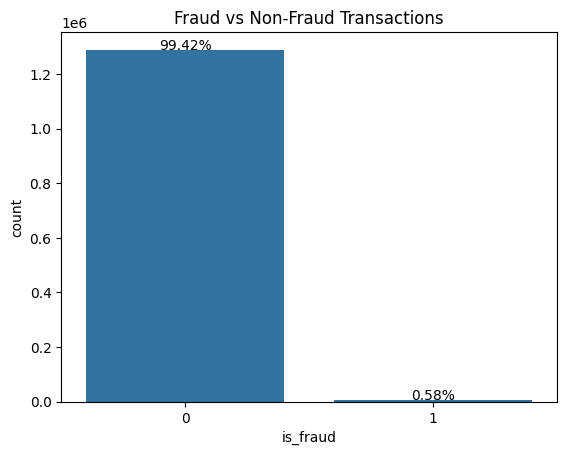

In [9]:
# 1. FRAUD DISTRIBUTION
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2,
             height,
             f'{(height/total)*100:.2f}%',
             ha='center')

plt.show()

In [ ]:
# 2. TRANSACTION AMOUNT DISTRIBUTION
sns.histplot(df['amt'], bins=50, kde=True)
plt.xlim(0, 2000)  
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
# 3. FRAUD VS AMOUNT (with outliers)
plt.figure()
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Fraud vs Amount")
plt.show()

In [ ]:
#Handling Outliers
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['amt'] >= lower_bound) & (df['amt'] <= upper_bound)]

In [ ]:
# 3. FRAUD VS AMOUNT (without outliers)
sns.boxplot(x='is_fraud', y='amt', data=df, showfliers=False)
plt.title("Fraud vs Transaction Amount")
plt.show()

In [ ]:
# 4. FRAUD BY CATEGORY
fraud_df = df[df['is_fraud'] == 1]

plt.figure(figsize=(10,5))
fraud_df['category'].value_counts().plot(kind='bar', color='red')
plt.title("Fraud Transactions by Category")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 5. FRAUD BY HOUR
fraud_df = df[df['is_fraud'] == 1]

sns.histplot(fraud_df['hour'], bins=24, color='red')
plt.title("Fraud Transactions by Hour")
plt.show()

In [ ]:
# 6. CORRELATION HEATMAP
cols_to_drop = ['Unnamed: 0', 'cc_num']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# 16. FINAL CONCLUSION

# Conclusion

# - The dataset is highly imbalanced.
# - Fraud transactions show different behavioral patterns.
# - Transaction amount, category, and time contribute useful insights.
# - Fraud detection is a complex problem requiring advanced techniques.